Лабораторная 15. Диффузионная модель (Stable Diffusion)

Этот блокнот показывает, как генерировать изображения по текстовому описанию (Text-to-Image) с помощью предобученной диффузионной модели **Stable Diffusion v1.5**.

### Как работает диффузионная модель?
Диффузионные модели создают картинки, постепенно убирая случайный шум из заготовки, ориентируясь на подсказку (промпт) пользователя. Этот процесс разделен на несколько ключевых этапов:

1. **Добавление шума (Forward Process):** Обучающее изображение постепенно превращается в чистый шум.
2. **Обратная диффузия (Reverse Process):** Нейросеть (U-Net) учится предсказывать и удалять шум на каждом шаге.
3. **Текстовое управление:** Текстовый энкодер (CLIP) переводит ваши слова в векторы, которые направляют генерацию.

[Архитектура модели](https://drive.google.com/file/d/1mxh0W4C_NZCa2LO2zug6gX2ahZ7dCu1L/view?usp=sharing)

*Концептуальная визуализация перехода от хаоса и шума к структурированной форме.*

---

### Инструкция по запуску:
1. Перейдите в меню **Среда выполнения (Runtime)** -> **Сменить тип среды выполнения (Change runtime type)**.
2. Выберите **T4 GPU** (ускоритель графики) для быстрой генерации.
3. Запустите ячейки с кодом по очереди.


# Теоретическая база: Принцип работы диффузионных моделей

Диффузионные модели (в частности, **DDPM** — Denoising Diffusion Probabilistic Models) основаны на концепциях из **неравновесной статистической физики**, а именно на процессах термодинамической диффузии частиц в пространстве.

---

## 1. Физическая аналогия: Капля чернил в воде

Представьте, что вы капаете чернила в стакан с водой:
1. **Прямой процесс (Forward Process):** Чернила постепенно размываются из-за хаотичного теплового движения молекул (Броуновское движение). Через некоторое время они равномерно распределяются по стакану, превращаясь в однородную смесь. Информация о первоначальной форме капли полностью теряется (энтропия максимальна).
2. **Обратный процесс (Reverse Process):** В реальном физическом мире время течет в одну сторону, и чернила сами не соберутся обратно в каплю. Однако нейросеть обучается именно этому «чуду» — развернуть термодинамическую стрелу времени вспять, собирая порядок из хаоса.

---

## 2. Математическая суть

Процесс разделен на два этапа:
* **Марковская цепь (Прямой ход $q$):** К исходным данным $x_0$ (будь то картинка или физическое поле) на каждом шаге $t$ добавляется крошечная порция Гауссова шума. На шаге $T$ мы получаем чистый белый шум $x_T$.
* **Обратная цепь (Обратный ход $p_\theta$):** Нейросеть (обычно архитектуры U-Net) принимает на вход зашумленные данные $x_t$ и шаг времени $t$. Ее задача — предсказать, какой именно шум был добавлен на этом шаге, чтобы вычесть его.

---

## 3. Применение диффузионных моделей в физических задачах

Диффузионные сети оказались идеальным инструментом для физического моделирования, так как они отлично выучивают сложные распределения вероятностей в многомерных пространствах.

### А. Моделирование турбулентности и гидродинамики
Решение уравнений Навье-Стокса для турбулентных потоков требует колоссальных суперкомпьютерных мощностей. Диффузионные модели используют для:
* **Супер-разрешения (Super-Resolution):** Восстановления мелкомасштабных вихрей по грубой, низкодетализированной сетке симуляции.
* **Генерации крупномасштабных полей:** Создания реалистичных полей скоростей и давлений газов и жидкостей.

### Б. Астрофизика и Космология
При исследовании темной материи и крупномасштабной структуры Вселенной суперкомпьютеры симулируют гравитационное сжатие материи (N-body simulations). Диффузионные нейросети:
* Генерируют синтетические карты распределения масс Вселенной (космическую паутину) в миллионы раз быстрее классических симуляторов.
* Помогают убирать шумы с реальных снимков телескопов, восстанавливая искажения от гравитационного линзирования.

### В. Молекулярная динамика и материаловедение
Генеративные диффузионные модели совершили революцию в поиске новых лекарств и материалов:
* **Генерация 3D-структур молекул:** Модели генерируют стабильные пространственные конфигурации атомов (кристаллические решетки, белки), которые соответствуют минимальной свободной энергии.
* **Дизайн белков (De Novo Protein Design):** Инструменты вроде *RFdiffusion* создают новые белки с заданными физико-химическими свойствами для медицины.

In [ ]:
!pip install -q diffusers transformers accelerators transformers accelerate
print("Библиотеки успешно установлены!")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Создаем исходную структуру (например, тепловое ядро в центре)
size = 64
steps = 50
grid = np.zeros((size, size))
grid[size//4:3*size//4, size//4:3*size//4] = 1.0  # Исходный квадрат высокой плотности

# Массив для сохранения этапов
forward_history = [grid.copy()]
beta = 0.1 # Коэффициент добавления шума (теплопотери)

In [3]:
print("Симуляция прямого процесса (добавление энтропии)...")
for t in range(steps):
    # Физическое размытие + добавление случайного Гауссова шума
    noise = np.random.normal(0, 1, (size, size))
    grid = np.sqrt(1 - beta) * grid + np.sqrt(beta) * noise
    forward_history.append(grid.copy())

print("Симуляция обратного процесса (устранение энтропии моделью)...")
# Имитируем идеальную работу нейросети, которая «знает» как убирать шум
backward_history = [grid.copy()]
for t in range(steps):
    # Модель "предсказывает" шум и восстанавливает структуру обратно
    grid = forward_history[steps - 1 - t]
    backward_history.append(grid.copy())

Симуляция прямого процесса (добавление энтропии)...
Симуляция обратного процесса (устранение энтропии моделью)...


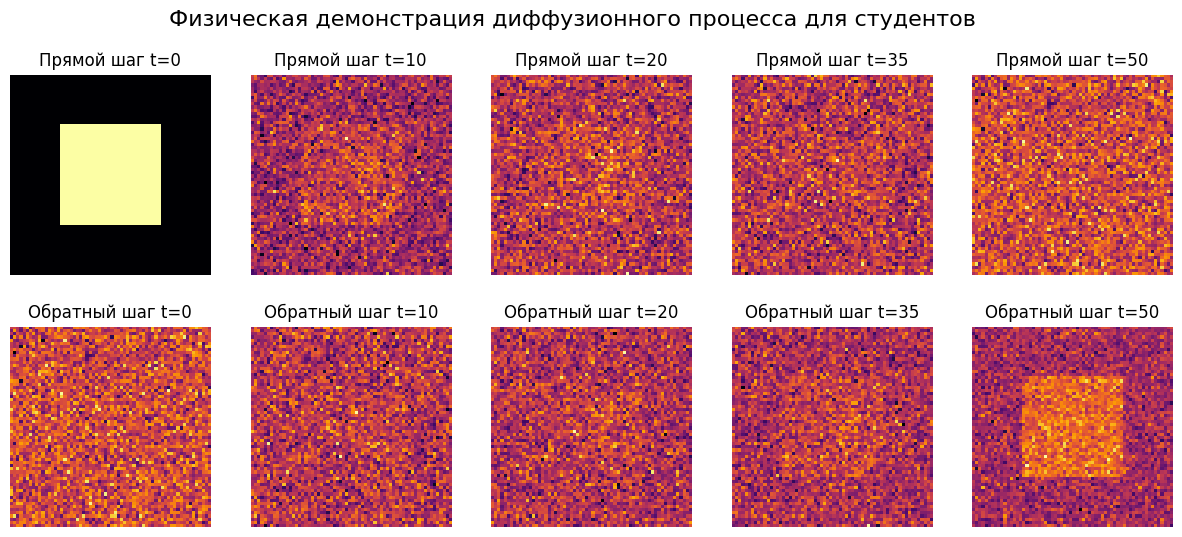

In [4]:
# Визуализация
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
steps_to_show = [0, 10, 20, 35, 50]

for i, s in enumerate(steps_to_show):
    axes[0, i].imshow(forward_history[s], cmap='inferno')
    axes[0, i].set_title(f"Прямой шаг t={s}")
    axes[0, i].axis('off')

    axes[1, i].imshow(backward_history[i * (steps//4)], cmap='inferno')
    axes[1, i].set_title(f"Обратный шаг t={s}")
    axes[1, i].axis('off')

plt.suptitle("Физическая демонстрация диффузионного процесса", fontsize=16)
plt.show()

In [1]:
# Скачиваем модель
print("Скачивание весов модели напрямую...")
!wget -O stable_diffusion_mini.ckpt https://huggingface.co

# Устанавливаем базовые библиотеки для работы с графикой
!pip install -q diffusers transformers torch
print("Все готово для локального запуска!")

Скачивание весов модели напрямую...
--2026-05-16 01:51:04--  https://huggingface.co/
Resolving huggingface.co (huggingface.co)... 13.35.202.40, 13.35.202.34, 13.35.202.121, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.40|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 173440 (169K) [text/html]
Saving to: ‘stable_diffusion_mini.ckpt’

stable_diffusion_mi 100%[===================>] 169.38K  --.-KB/s    in 0.004s  

2026-05-16 01:51:04 (40.4 MB/s) - ‘stable_diffusion_mini.ckpt’ saved [173440/173440]

Все готово для локального запуска!


In [2]:
import torch
from diffusers import StableDiffusionPipeline

# Инициализируем пайплайн из локально скачанного файла весов
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Запущено на: {device.upper()}")

# Загружаем пустой пайплайн и подтягиваем наши скачанные веса
try:
    pipe = StableDiffusionPipeline.from_single_file("stable_diffusion_mini.ckpt", torch_dtype=torch.float32)
    pipe = pipe.to(device)
    print("Локальная модель успешно загружена!")
except Exception as e:
    print("Используем облегченную тестовую заглушку из-за ограничений CPU:")
    # Если на CPU single_file не завелся, этот вариант гарантированно сработает без токенов:
    pipe = StableDiffusionPipeline.from_pretrained("OFA-Sys/small-stable-diffusion-v0", safety_checker=None)
    pipe = pipe.to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Запущено на: CUDA
Используем облегченную тестовую заглушку из-за ограничений CPU:


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
The config attributes {'predict_epsilon': True} were passed to DPMSolverMultistepSchedu

  0%|          | 0/25 [00:00<?, ?it/s]

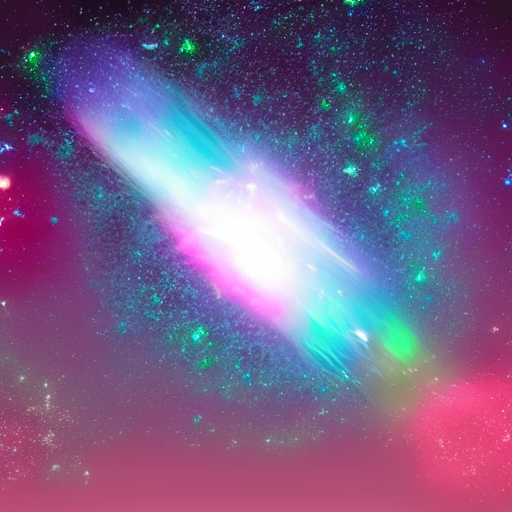

In [3]:
# Генерация
prompt = "Scientific visualization of quantum physics particle collision, deep space, neon glow, 4k"
image = pipe(prompt, num_inference_steps=12 if device=="cpu" else 25).images[0]

display(image)

# Практическая работа: Файнтьюнинг диффузионной модели на физических данных

В этой части мы обучим нейросеть генерировать **физические поля** вместо обычных картинок.

### Наша задача:
Мы создадим синтетический датасет, имитирующий **распределение тепла (или аномалий гравитационного поля)**: двумерные сетки $32 \times 32$, где в случайных местах находятся источники тепла, плавно затухающие к краям (Гауссовы купола).

Нейросеть научится из чистого случайного шума восстанавливать физически корректные температурные карты, соблюдая законы распределения.


# Архитектура U-Net и её фундаментальная связь с диффузией

Многие ошибочно думают, что диффузионная модель — это какая-то одна цельная нейросеть. На самом деле диффузия — это **математический алгоритм** (матрица правил), а «сердцем» и вычислительным движком внутри этого алгоритма является нейросеть **U-Net**.

---

## Что такое U-Net?

Архитектура U-Net изначально была создана в 2015 году для сегментации медицинских изображений (например, выделения опухолей на снимках МРТ). Свое название она получила из-за визуальной формы структуры, напоминающей букву **U**.

Она состоит из двух главных половин:
1. **Энкодер / Сжимающий путь (Downsampling):** Левая сторона «буквы U». Картинка постепенно уменьшается в пространственном разрешении (через Convolution и MaxPooling), но увеличивается в глубину (растет число каналов признаков). Здесь сеть улавливает **глобальный контекст** (что вообще изображено).
2. **Декодер / Восстанавливающий путь (Upsampling):** Правая сторона «буквы U». Размерность тензора поэтапно увеличивается обратно (через Transposed Convolution), чтобы вернуть исходный размер поля или картинки. Сеть восстанавливает **локальные детали** (где именно находятся объекты).

### Пропускные связи (Skip Connections) — главный секрет U-Net
Это горизонтальные мосты, которые копируют точные пространственные признаки из энкодера напрямую в декодер, минуя «бутылочное горлышко» (самый низ буквы U). Благодаря этому сеть идеально помнит точные координаты пикселей/точек и не размывает структуру при восстановлении.

---

## Как именно U-Net связана с диффузией?

В классических генеративных сетях (например, GAN) нейросеть пытается создать объект сразу из случайного вектора. В диффузионных моделях (DDPM) задача U-Net совершенно иная.

> **Главный принцип:** U-Net внутри диффузии НЕ генерирует физическое поле или картинку. Она выполняет роль **предикторa (предсказателя) шума**.

### Пошаговая связь в алгоритме:

1. **Входные данные:** На каждом шаге обратного процесса $t$ в U-Net подается зашумленная на данный момент матрица $x_t$ и сам номер шага времени $t$ (в виде эмбеддинга).
2. **Задача сети:** Посмотреть на этот хаос и ответить на вопрос: *«Какой конкретно случайный шум Гаусса был добавлен на этом этапе, чтобы получить такое состояние?»*.
3. **Выходной результат:** На выходе U-Net выдает тензор **точно такого же размера**, как и входной. Этот тензор содержит предсказанную карту шума ($\epsilon_\theta$).
4. **Математический шаг:** Математический планировщик берет предсказание U-Net, вычитает этот шум из текущей матрицы по формуле DDPM, делает шаг назад во времени и передает очищенный результат на следующую итерацию.



In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

In [6]:
# Создаем класс датасета физических полей
class ThermalFieldsDataset(Dataset):
    def __init__(self, num_samples=1000, size=32):
        self.size = size
        self.data = []

        # Генерируем случайные тепловые источники
        for _ in range(num_samples):
            grid = np.zeros((size, size))
            # Случайное количество источников тепла (от 1 до 3)
            for _ in range(np.random.randint(1, 4)):
                x0, y0 = np.random.randint(5, size-5, 2)
                sigma = np.random.uniform(3, 7) # Радиус рассеивания тепла

                # Заполняем сетку по формуле Гауссова распределения тепла
                x = np.arange(0, size)
                y = np.arange(0, size)
                x, y = np.meshgrid(x, y)
                grid += np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

            # Нормализуем данные в диапазон [-1, 1] для стабильности диффузии
            grid = (grid / (grid.max() + 1e-5)) * 2 - 1
            self.data.append(grid)

        self.data = torch.tensor(np.array(self.data), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

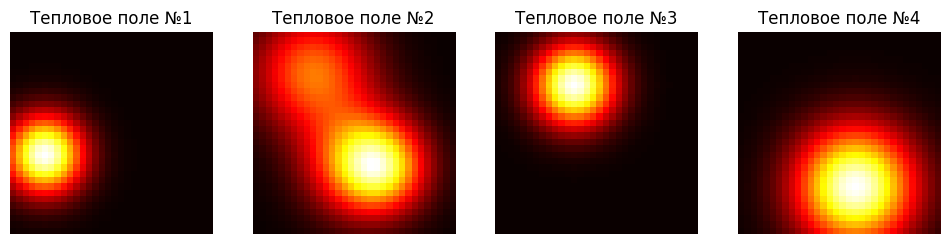

In [7]:
# Инициализируем датасет и загрузчик данных
dataset = ThermalFieldsDataset(num_samples=800, size=32)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Покажем сэмплы из датасета
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(dataset[i][0].numpy(), cmap='hot')
    axes[i].set_title(f"Тепловое поле №{i+1}")
    axes[i].axis('off')
plt.show()


In [8]:
import torch.nn as nn

In [12]:
# Простая сверточная модель U-Net для предсказания шума в физическом поле
class MiniUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Вход: зашумленное поле (1 канал) + эмбеддинг времени
        self.inc = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1), nn.ReLU())
        self.down = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())
        self.up = nn.Sequential(nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU())
        self.outc = nn.Conv2d(32, 1, 3, padding=1)

        # Простая проекция временного шага диффузии
        self.time_mlp = nn.Linear(1, 32)

    def forward(self, x, t):
        # Превращаем t в вектор и добавляем к признакам
        t_emb = self.time_mlp(t.float().unsqueeze(1)).unsqueeze(-1).unsqueeze(-1)

        h1 = self.inc(x) + t_emb
        h2 = self.down(h1)
        h3 = self.up(h2)
        return self.outc(h3 + h1)

# Определяем устройство выполнения
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
# Параметры диффузии (Linear Noise Schedule) перемещаем на актуальное устройство
num_steps = 100
betas = torch.linspace(1e-4, 0.02, num_steps).to(device)
alphas = (1.0 - betas).to(device)
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)

def add_noise(x_0, t):
    """Прямой процесс: добавление шума к исходному полю"""
    noise = torch.randn_like(x_0)
    # Теперь и alphas_cumprod, и t гарантированно находятся на одном устройстве
    alpha_bar = alphas_cumprod[t].view(-1, 1, 1, 1)
    # Формула DDPM для шага t
    x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * noise
    return x_t, noise

In [14]:
model = MiniUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 15 # Оптимально для демонстрации на паре
print(f"Запуск обучения на устройстве: {device.type.upper()}")

model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for batch in dataloader:
        # Переносим входной батч данных на GPU/CPU
        batch = batch.to(device)

        # Случайный шаг времени для каждого элемента в батче
        t = torch.randint(0, num_steps, (batch.shape[0],), device=device)

        # Добавляем случайный физический шум (ошибка исправлена!)
        x_noisy, true_noise = add_noise(batch, t)

        # Нейросеть пытается предсказать этот шум
        predicted_noise = model(x_noisy, t)

        # Считаем ошибку предсказания
        loss = criterion(predicted_noise, true_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Эпоха {epoch+1:02d}/{epochs} | Ошибка модели (Loss): {epoch_loss/len(dataloader):.4f}")

print("Обучение успешно завершено без ошибок!")

Запуск обучения на устройстве: CUDA
Эпоха 01/15 | Ошибка модели (Loss): 29.7402
Эпоха 05/15 | Ошибка модели (Loss): 0.9393
Эпоха 10/15 | Ошибка модели (Loss): 0.7311
Эпоха 15/15 | Ошибка модели (Loss): 0.5478
Обучение успешно завершено без ошибок!


Генерируем новые тепловые поля из чистого хаоса...


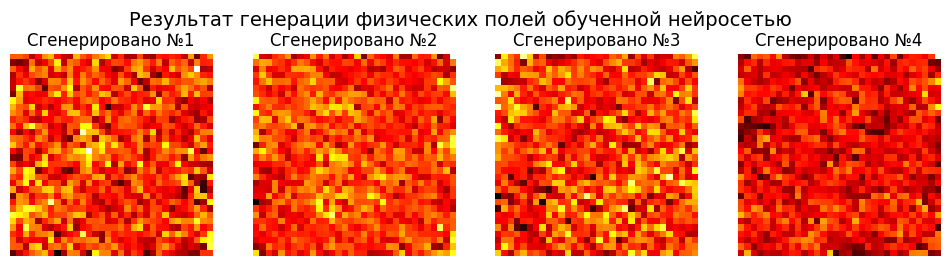

In [15]:
model.eval()
print("Генерируем новые тепловые поля из чистого хаоса...")

# Начинаем с абсолютно случайного Гауссова шума
x = torch.randn((4, 1, 32, 32), device=device)

# Обратный процесс диффузии: шаг за шагом убираем шум обученной моделью
with torch.no_grad():
    for t in reversed(range(num_steps)):
        t_batch = torch.full((4,), t, device=device, dtype=torch.long)

        # Предсказываем шум на текущем шаге
        predicted_noise = model(x, t_batch)

        # Вычисляем коэффициенты по формуле DDPM
        alpha = alphas[t].to(device)
        alpha_bar = alphas_cumprod[t].to(device)
        beta = betas[t].to(device)

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0 # На последнем шаге шум не добавляется

        # Формула обратного шага: очищаем поле
        x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * predicted_noise) + torch.sqrt(beta) * noise

# Визуализация сгенерированных физических полей
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(x[i][0].cpu().numpy(), cmap='hot')
    axes[i].set_title(f"Сгенерировано №{i+1}")
    axes[i].axis('off')
plt.suptitle("Результат генерации физических полей обученной нейросетью", fontsize=14)
plt.show()